In [10]:
from dotenv import load_dotenv
load_dotenv()
import os

In [18]:
from langchain_tavily import TavilySearch

tool = TavilySearch(
    max_results=3,
    topic="general",
    include_images=False,
    include_image_descriptions=False,
)

In [19]:
# Basic usage
results = tool.invoke({"query": "What happened at the last wimbledon"})

In [20]:
results

{'query': 'What happened at the last wimbledon',
 'response_time': 0.66,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.nbcnews.com/sports/tennis/novak-djokovic-grand-slam-wimbledon-final-rcna217887',
   'title': "Novak Djokovic's Grand Slam title drought continues after ...",
   'content': "# Novak Djokovic's Grand Slam title drought continues after Wimbledon semifinal loss. When Novak Djokovic won his seventh men’s singles championship at Wimbledon in 2022 — the fourth consecutive year he’d won the iconic grass-court tournament — it appeared only a matter of time before he would win again and match Roger Federer for the most titles in the tournament's history. Instead, for three consecutive years, Djokovic, the Serbian superstar who owns the most Grand Slam titles in tennis history, has been denied that place atop Wimbledon's all-time leaderboard as his grip on Grand Slam tournaments has loosened. Following losses in the 2023 and 2024 

In [12]:
from pywa import WhatsApp, types, filters
from fastapi import FastAPI
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage,RemoveMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langgraph.checkpoint.postgres import PostgresSaver
from langchain_core.prompts import PromptTemplate
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode
from langchain.tools import tool
from typing import TypedDict, Annotated
import psycopg
import os,time
import shutil
import json
import PyPDF2
from typing import List
from pydantic import BaseModel, Field
from typing import Literal
from langgraph.store.base import BaseStore
from langchain_core.runnables import RunnableConfig
from langgraph.store.postgres import PostgresStore
from langchain_tavily import TavilySearch

In [38]:
best_result = max(results['results'], key=lambda x: x['score'])
print("source =",best_result['url'])
print("content =",best_result['content'])

source = https://www.cnn.com/sport/live-news/wimbledon-final-mens-25-07-13-spt
content = # Jannik Sinner beats Carlos Alcaraz to win his first Wimbledon title. • **Men’s singles champion:** World No. 1 Jannik Sinner won his first Wimbledon title in a hard-fought battle with two-time reigning champion Carlos Alcaraz. Jannik Sinner is the men’s singles champion at Wimbledon for the first time after he came from a set down to beat two-time defending champion Carlos Alcaraz, 4-6, 6-4, 6-4, 6-4. Sinner looked to have taken control in the first set when he broke his opponent’s serve in the fifth game to take a 3-2 lead, only for Alcaraz to break back twice — the second time thanks in part to a suddenly nervous looking Sinner, who double-faulted to give the Spaniard an advantage, which he wasted no time in taking. Jannik Sinner defeats Carlos Alcaraz 4-6, 6-4, 6-4, 6-4 to win his first Wimbledon title. ## Alcaraz holds to make it 5-4, but Sinner serving for Wimbledon title. Alcaraz holds but 

In [7]:
query="hi"
type(query)
if(type(query)==str):  print('here')

here


In [14]:
class state_chatbot(TypedDict):
    messages:Annotated[list[BaseMessage], add_messages]
    msg_id:str

class summary_messages(state_chatbot): #inherits from state_chatbot
    summary:str

In [18]:
def remember_node(state: summary_messages, config: RunnableConfig,  store: BaseStore):

    user_id = config["configurable"]["thread_id"]
    ns = ("user", user_id, "details")

    # existing memory (all items under namespace)
    items = store.search(ns)
    existing = "\n".join(it.value.get("data", "") for it in items) if items else "(empty)"

    # latest user message
    last_text = state["messages"][-1].content

    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=existing)),
            HumanMessage(content=last_text),
        ]
    )
    
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new and mem.text.strip():
                # msg.id is used as key for memory
                store.put(ns, state["msg_id"], {"data": mem.text.strip()})

    return {}

def chatbot(state:summary_messages,config :RunnableConfig,store:BaseStore):

    message=[] # temporary list to store messages it will be combined with summary and state['messages']

    user_id = config["configurable"]["thread_id"]
    ns = ("user", user_id, "details") # name space for LTM
    
    items = store.search(ns)
    user_details = "\n".join(it.value.get("data", "") for it in items) if items else ""

    # Inject LTM context into the unified system prompt from prompts.json
    system_msg = SystemMessage(
        content=data["system_prompt"].format(user_details_content=user_details or "(empty)")
    )

    if state.get('summary'):
        message.append(
            HumanMessage(content=f"converstaion summary \n{state['summary']}")
        )

    message.extend(state['messages'])
    response=llm.invoke(message +[system_msg]) 
    return {'messages':[response]}
    
def summarize_conversation(state:summary_messages):
    
    exsisting_summary=state.get("summary")

    if exsisting_summary:

        prompt=f"exsisting_summary\n{exsisting_summary}\n\n extend the summary using new conversation above"

    else :
        prompt="suumarize the conversation"

    message_and_summary=state["messages"]+[HumanMessage(content=prompt)] # all messages + summary 

    new_summary=llm.invoke(message_and_summary)

    # all messages except last 2
    message_to_delete=state["messages"][:-2]

    return {
        "summary":new_summary.content,
        "messages":[RemoveMessage(id=m.id) for m in message_to_delete],
    }


def search_summarizer_checker(state:summary_messages):
    last_message = state["messages"][-1]
    # Check 1: Does the LLM want to call a tool?
    if last_message.tool_calls:
        return "tools"
    # Check 2: Should we summarize?
    if len(state["messages"]) > 10:
        return "summarize"
    return "end"
@tool
def web_search(query:str):
    """Search the web for information."""
    results= search_tool.invoke({"query": query})
    best_result = max(results['results'], key=lambda x: x['score'])
    return f"for title: {best_result['title']} \n\n from source: {best_result['url']} \n\n the content is: {best_result['content']}"



In [21]:

graph=StateGraph(summary_messages)

graph.add_node("remember", remember_node)
graph.add_node('chatbot',chatbot)
graph.add_node('summarize_conversation',summarize_conversation)
graph.add_node("tools", ToolNode([web_search]))

graph.add_edge(START,'remember')
graph.add_edge("remember","chatbot")
graph.add_conditional_edges(
        'chatbot',
        search_summarizer_checker,
        {
            "tools": "tools",
            "summarize": "summarize_conversation",
            "end": END
        }
    )
graph.add_edge("tools", "chatbot")
graph.add_edge('summarize_conversation',END)
    
workflow = graph.compile()
print (workflow)

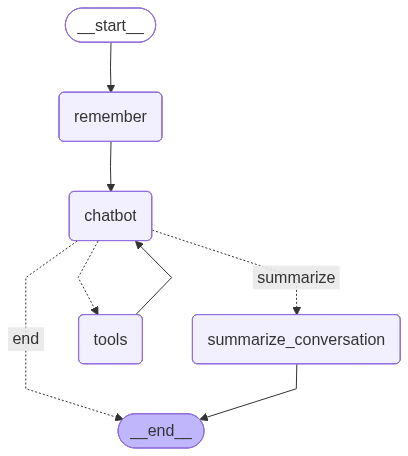

In [22]:
workflow

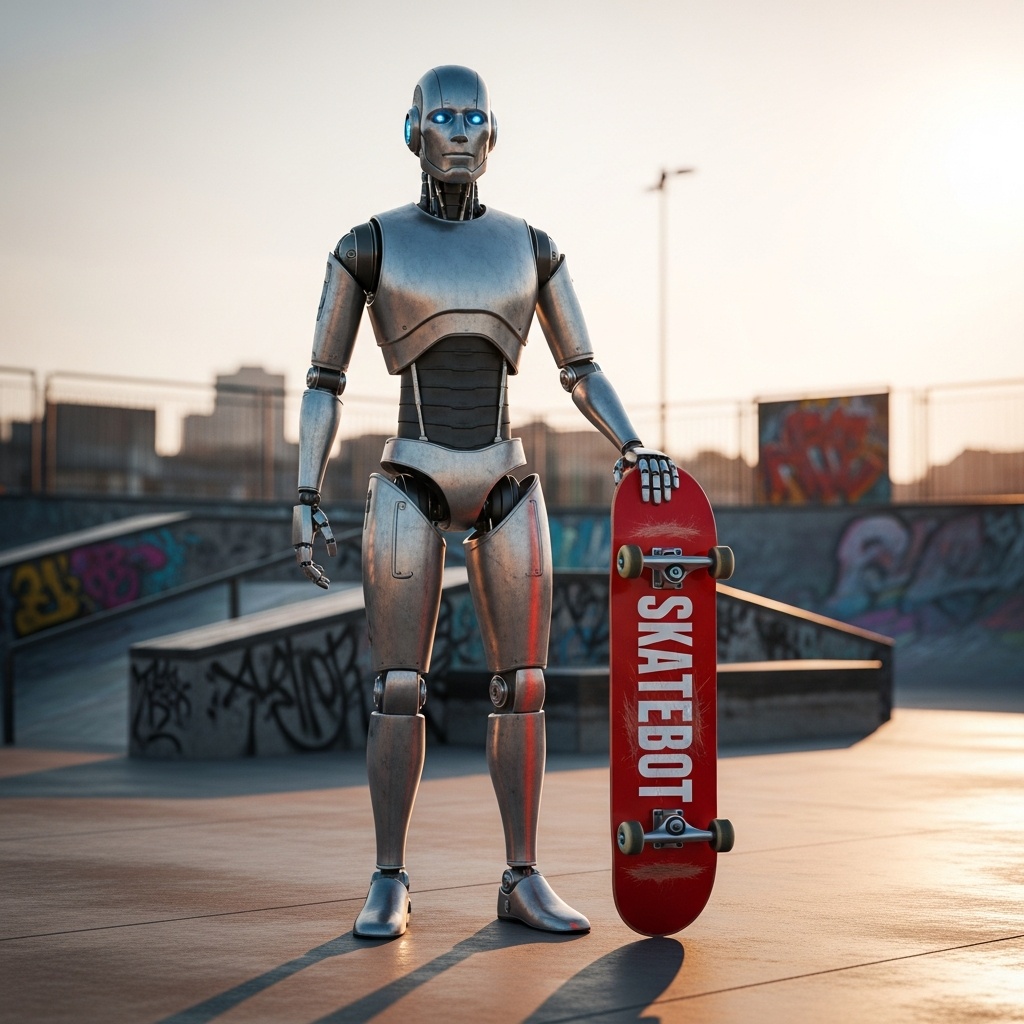

In [6]:
import os
from google import genai
from PIL import Image
from io import BytesIO
# Make sure your API key is loaded
api_key = os.environ.get("GOOGLE_API_KEY")
# Initialize the client normally
client = genai.Client(api_key=api_key)
# Generate the image
response = client.models.generate_images(
    model='imagen-4.0-generate-001',
    prompt='Robot holding a red skateboard',
    config=dict(
        number_of_images=1,
    )
)
# Display it
for generated_image in response.generated_images:
    image = Image.open(BytesIO(generated_image.image.image_bytes))
    display(image)

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=os.getenv("GOOGLE_API_KEY"),
    temperature=0.3,
)


In [13]:
from langchain_core.messages import HumanMessage
import base64

image_data = base64.b64encode(open("test.png", "rb").read()).decode()

msg = HumanMessage(content=[
    {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{image_data}"}},
    {"type": "text", "text": "what's in this?"},
])



In [16]:
image_data

'...'

HumanMessage(content=[{'type': 'image_url', 'image_url': {'url': ''}}, {'type': 'text', 'text': "what's in this?"}], additional_kwargs={}, response_metadata={})
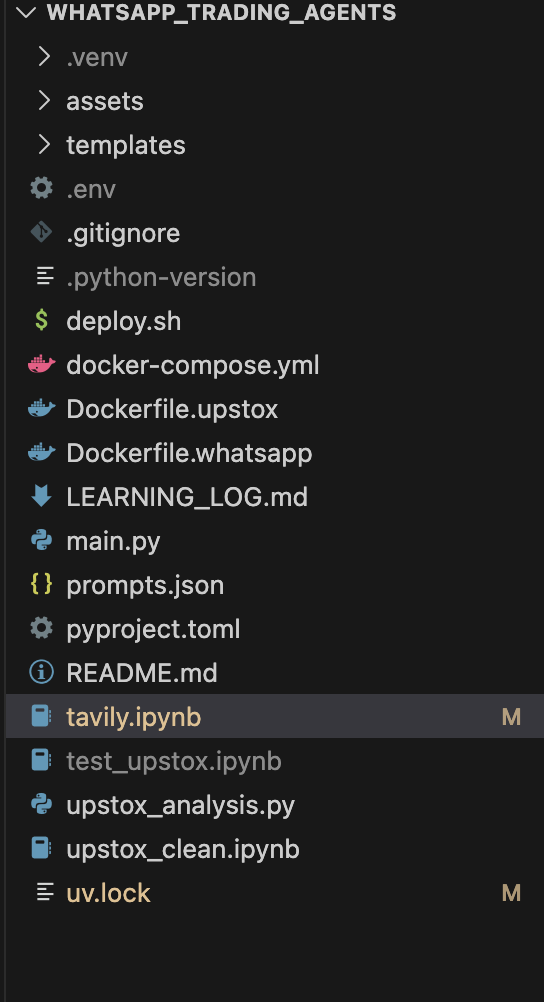

In [14]:
msg

In [15]:
llm.invoke([msg])

AIMessage(content='This image displays a file directory structure, likely from an IDE like VS Code, for a project named **WHATSAPP_TRADING_AGENTS**.\n\nIt contains the following folders:\n*   `.venv` (a Python virtual environment)\n*   `assets`\n*   `templates`\n\nAnd the following files:\n*   `.env` (environment variables)\n*   `.gitignore` (Git ignore file)\n*   `.python-version` (specifying Python version)\n*   `deploy.sh` (a shell script for deployment)\n*   `docker-compose.yml` (Docker Compose configuration)\n*   `Dockerfile.upstox` (Dockerfile for an Upstox-related service)\n*   `Dockerfile.whatsapp` (Dockerfile for a WhatsApp-related service)\n*   `LEARNING_LOG.md` (a Markdown log file)\n*   `main.py` (the main Python script)\n*   `prompts.json` (a JSON file, likely containing prompts or configurations)\n*   `pyproject.toml` (Python project configuration, e.g., for Poetry or PDM)\n*   `README.md` (project documentation)\n*   `tavily.ipynb` (Jupyter Notebook, marked as modified w